## **EXPLORACIÓN DEL DATASET DMID_PNG**

Este notebook tiene como objetivo realizar un análisis exploratorio del dataset DMID_PNG (Digital Mammography Dataset for Breast Cancer Diagnosis Research), con el fin de comprender su estructura, calidad y distribución antes de su uso en modelos de deep learning.

En esta fase se lleva a cabo la carga del dataset y la inspección de sus principales componentes: imágenes mamográficas en formato TIFF, máscaras binarias asociadas y anotaciones a nivel de píxel (PLA). Además, se realiza una visualización representativa de ejemplos del conjunto de datos para entender la correspondencia entre imágenes y sus etiquetas. También se incluye un análisis estadístico básico, donde se estudian aspectos como el rango de valores de los píxeles, la distribución de intensidades y la cobertura de las anotaciones. Este análisis permite evaluar la calidad del dataset y detectar posibles problemas como desbalance o ruido en las etiquetas.

Finalmente, se generan diferentes visualizaciones (histogramas, distribuciones y grids de imágenes) que facilitan la interpretación del conjunto de datos y proporcionan una base sólida para las siguientes fases del proyecto, como el preprocesamiento y el entrenamiento de modelos de redes neuronales convolucionales.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import re 
import random
import warnings
warnings.filterwarnings('ignore')

### **CARGA DEL DATASET**

In [ ]:
# Rutas principales
BASE       = Path("..") / "DMID_PNG"          # raíz del dataset
BASE_1024  = BASE / "1024"                    # resolución 1024 (alta calidad)
META_PATH  = BASE / "Metadata.xlsx"           # metadata
OUT_DIR    = Path("..") / "data"              # carpeta de salida para CSVs
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path :", BASE.resolve())
print("Metadata path:", META_PATH.resolve())
print("Output dir   :", OUT_DIR.resolve())

Dataset path : C:\Users\Usuario\Desktop\TERCERO CARRERA\2º CUATRI\Redes Neuronales\trabajo\breast-cancer\DMID_PNG
Metadata path: C:\Users\Usuario\Desktop\TERCERO CARRERA\2º CUATRI\Redes Neuronales\trabajo\breast-cancer\DMID_PNG\Metadata.xlsx
Output dir   : C:\Users\Usuario\Desktop\TERCERO CARRERA\2º CUATRI\Redes Neuronales\trabajo\breast-cancer\data


USANDO CARPETA 1024 (alta resolución)
Total archivos encontrados : 1052
----------------------------------------
  Imágenes originales : 511
  Máscaras            : 269
  PLA                 : 269


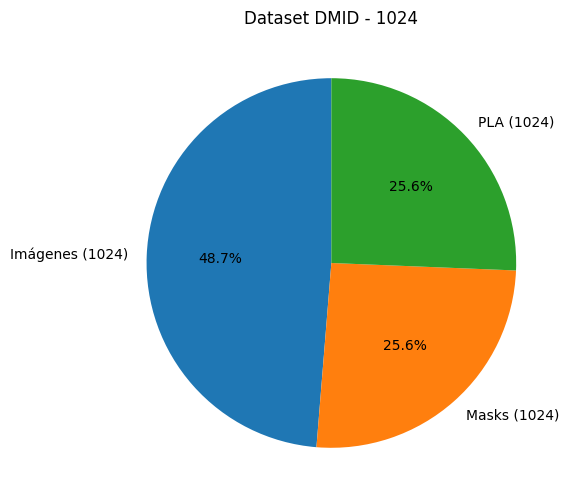

In [ ]:
all_files = list(BASE_1024.rglob("*"))

# Separar por tipo
imgs  = [p for p in all_files if p.is_file() and p.suffix.lower() in (".png", ".tif", ".tiff") and "mask" not in str(p).lower() and "pla" not in str(p).lower()]
masks = [p for p in all_files if p.is_file() and "mask" in str(p).lower()]
plas  = [p for p in all_files if p.is_file() and "pla"  in str(p).lower()]

print("USANDO CARPETA 1024 (alta resolución)")
print(f"Total archivos encontrados : {len(all_files)}")
print("-" * 40)
print(f"  Imágenes originales : {len(imgs)}")
print(f"  Máscaras            : {len(masks)}")
print(f"  PLA                 : {len(plas)}")

# gráfico visual
plt.figure(figsize=(6,6))
plt.pie(
    [len(imgs), len(masks), len(plas)],
    labels=["Imágenes (1024)", "Masks (1024)", "PLA (1024)"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Dataset DMID - 1024")
plt.show()

### **ESTUDIO DEL METADATA**

In [ ]:
meta_path = BASE / "Metadata.xlsx"
raw = pd.read_excel(meta_path, header=None)

df = raw.copy()

df.columns = [
    "image_id",
    "view",
    "tissue",
    "abnormality_type",
    "class",
    "x",
    "y",
    "radius"
]

# solo filas reales
df = df[df["image_id"].astype(str).str.contains("IMG", na=False)].copy()

# limpiar espacios y normalizar tipos
# strip whitespace for string columns (preserve NaN)
str_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in str_cols:
    df[c] = df[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

# convertir columnas numéricas
for col in ["x", "y", "radius"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# directorio de salida: carpeta 'data' en la raíz del proyecto (fuera de DMID_PNG)
out_dir = Path("..") / "data"
out_dir.mkdir(parents=True, exist_ok=True)

# guardar en CSV y Parquet (necesita pyarrow o fastparquet instalado)
csv_path = out_dir / "metadata_clean.csv"
parquet_path = out_dir / "metadata_clean.parquet"
df.to_csv(csv_path, index=False)
try:
    df.to_parquet(parquet_path, index=False, engine="pyarrow")
except Exception as e:
    print("Warning: could not write parquet. Install pyarrow or fastparquet and restart the kernel.\n", e)

# Guardar CSV Y parquet limpio
csv_path = OUT_DIR / "metadata_clean.csv"
parquet_path = OUT_DIR / "metadata_clean.parquet"
df.to_csv(csv_path, index=False)
try:
    df.to_parquet(parquet_path, index=False, engine="pyarrow")
except Exception as e:
    print("Warning: could not write parquet. Install pyarrow or fastparquet and restart the kernel.\n", e)

print(f"- Metadata guardado en: {csv_path}")
print(f"- Metadata guardado en: {parquet_path}")

print(f"\nRegistros totales  : {len(df)}")
print(f"IDs únicos         : {df['image_id'].nunique()}")
print(f"\nDistribución de clases:")
print(df["class"].value_counts(dropna=False).to_string())

df.head(10)

- Metadata guardado en: ..\data\metadata_clean.csv
- Metadata guardado en: ..\data\metadata_clean.parquet

Registros totales  : 647
IDs únicos         : 510

Distribución de clases:
class
B      253
NaN    200
M      158
N       36


,image_id,view,tissue,abnormality_type,class,x,y,radius
31,IMG001,MLOLT,G,MISC+CALC,M,1567.0,3644.0,295.0
32,IMG001,MLOLT,G,CIRC,B,1461.0,3102.0,85.0
33,IMG002,MLORT,G,NORM,NaN,NaN,NaN,NaN
34,IMG003,CCLT,F,NORM,NaN,NaN,NaN,NaN
35,IMG004,CCRT,F,NORM,NaN,NaN,NaN,NaN
36,IMG005,MLOLT,F,NORM,NaN,NaN,NaN,NaN
37,IMG006,MLORT,F,NORM,NaN,NaN,NaN,NaN
38,IMG007,CCLT,G,NORM,NaN,NaN,NaN,NaN
39,IMG008,CCRT,G,CIRC,B,3211.0,3904.0,216.0
40,IMG009,MLOLT,G,NORM,NaN,NaN,NaN,NaN


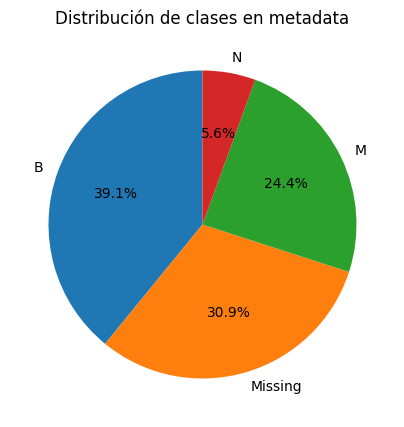

In [ ]:
# Gráfico de distribución de clases
class_counts = df["class"].value_counts(dropna=False)
labels = [
    "Missing" if (pd.isna(x) or (isinstance(x, str) and x.strip() == "")) else str(x)
    for x in class_counts.index
]

plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Distribución de clases en metadata")
plt.show()

### **ESTUDIO SOBRE LAS IMÁGENES DEL DATASET**

In [ ]:
def extract_id(path):
    """Extrae el ID normalizado (ej. 'img001') desde el nombre de archivo."""
    match = re.search(r'(img\d+)', path.stem.lower())
    return match.group(1) if match else None

def extract_id_from_str(s):
    """Extrae el ID normalizado desde un string cualquiera (ej. 'IMG001')."""
    match = re.search(r'(img\d+)', str(s).lower())
    return match.group(1) if match else None

# Indexar ficheros por ID
img_dict  = {extract_id(p): p for p in imgs  if extract_id(p)}
mask_dict = {extract_id(p): p for p in masks if extract_id(p)}
pla_dict  = {extract_id(p): p for p in plas  if extract_id(p)}

print("INDEXACIÓN COMPLETADA")
print("-" * 40)
print(f"  Imágenes indexadas : {len(img_dict)}")
print(f"  Máscaras indexadas : {len(mask_dict)}")
print(f"  PLA indexados      : {len(pla_dict)}")

INDEXACIÓN COMPLETADA
----------------------------------------
  Imágenes indexadas : 510
  Máscaras indexadas : 269
  PLA indexados      : 269


In [ ]:
pairs        = []   # casos con img + mask + pla
missing_mask = []   # ids sin máscara
missing_pla  = []   # ids sin PLA

for k, img_path in img_dict.items():
    mask_path = mask_dict.get(k)
    pla_path  = pla_dict.get(k)

    if mask_path and pla_path:
        pairs.append({"id": k, "image": img_path, "mask": mask_path, "pla": pla_path})
    else:
        if not mask_path:
            missing_mask.append(k)
        if not pla_path:
            missing_pla.append(k)

print("EMPAREJAMIENTO FINAL")
print("-" * 40)
print(f"  Casos completos (img + mask + pla) : {len(pairs)}")
print(f"  Sin máscara                        : {len(missing_mask)}")
print(f"  Sin PLA                            : {len(missing_pla)}")

if missing_mask:
    print(f"\nEjemplos sin máscara : {missing_mask[:5]}")
if missing_pla:
    print(f"Ejemplos sin PLA     : {missing_pla[:5]}")

EMPAREJAMIENTO FINAL
----------------------------------------
  Casos completos (img + mask + pla) : 269
  Sin máscara                        : 241
  Sin PLA                            : 241

Ejemplos sin máscara : ['img002', 'img003', 'img004', 'img005', 'img006']
Ejemplos sin PLA     : ['img002', 'img003', 'img004', 'img005', 'img006']


In [ ]:
# Conjuntos de IDs por categoría (usando metadata)
norm_ids   = set(extract_id_from_str(i) for i in df[df["class"] == "NORM"]["image_id"].unique())
lesion_ids = set(extract_id_from_str(i) for i in df[(df["class"] != "NORM") & df["class"].notna()]["image_id"].unique())
masked_ids = set(mask_dict.keys())

print(f"IDs NORM (sin lesión)         : {len(norm_ids)}")
print(f"IDs con lesión (no NORM)      : {len(lesion_ids)}")
print(f"IDs con máscara en disco      : {len(masked_ids)}")

IDs NORM (sin lesión)         : 0
IDs con lesión (no NORM)      : 310
IDs con máscara en disco      : 269


### **COMPROBACIONES SOBRE LAS IMÁGENES Y EL METADATA**

In [ ]:
norm_con_mascara = norm_ids & masked_ids   # intersección: NORM que SÍ tienen máscara

print("=" * 60)
print("REGLA 1 – NORM sin máscara")
print("=" * 60)
print(f"\nImágenes NORM con máscara (anomalía) : {len(norm_con_mascara)}")

if len(norm_con_mascara) == 0:
    print("- CORRECTO: ninguna imagen NORM tiene máscara asociada.")
else:
    print("- PROBLEMA: las siguientes imágenes NORM tienen máscara (revisar):")
    for img_id in sorted(norm_con_mascara):
        print(f"   - {img_id}")

REGLA 1 – NORM sin máscara

Imágenes NORM con máscara (anomalía) : 0
- CORRECTO: ninguna imagen NORM tiene máscara asociada.


In [ ]:
lesion_sin_mascara = lesion_ids - masked_ids   # diferencia: lesión sin máscara
lesion_con_mascara = lesion_ids & masked_ids

print("=" * 60)
print("REGLA 2 – Imágenes con lesión y sin máscara")
print("=" * 60)
print(f"\nImágenes con lesión + máscara disponible : {len(lesion_con_mascara)}")
print(f"Imágenes con lesión SIN máscara          : {len(lesion_sin_mascara)}")

if len(lesion_sin_mascara) == 0:
    print("\n- CORRECTO: todas las imágenes con lesión tienen máscara.")
else:
    integridad = len(lesion_con_mascara) / len(lesion_ids) * 100
    print(f"\n- Integridad: {integridad:.1f}% de las lesiones tienen máscara")
    print("\n- Ejemplos sin máscara (primeros 10):")
    for img_id in sorted(lesion_sin_mascara)[:10]:
        print(f"   - {img_id}")

    # Distribución de clases entre las problemáticas
    problem_ids_orig = df["image_id"].apply(extract_id_from_str).isin(lesion_sin_mascara)
    problem_df = df[problem_ids_orig]
    print("\nDistribución de clases en imágenes sin máscara:")
    print(problem_df["class"].value_counts().to_string())

REGLA 2 – Imágenes con lesión y sin máscara

Imágenes con lesión + máscara disponible : 269
Imágenes con lesión SIN máscara          : 41

- Integridad: 86.8% de las lesiones tienen máscara

- Ejemplos sin máscara (primeros 10):
   - img018
   - img019
   - img020
   - img022
   - img023
   - img028
   - img037
   - img038
   - img040
   - img055

Distribución de clases en imágenes sin máscara:
class
N    35
M     5
B     2


- ESTUDIO:
  - NORM total: 0
  - NORM con máscara: 0
  - NORM sin máscara: 0
  - Lesión con máscara: 269
  - Lesión sin máscara: 41


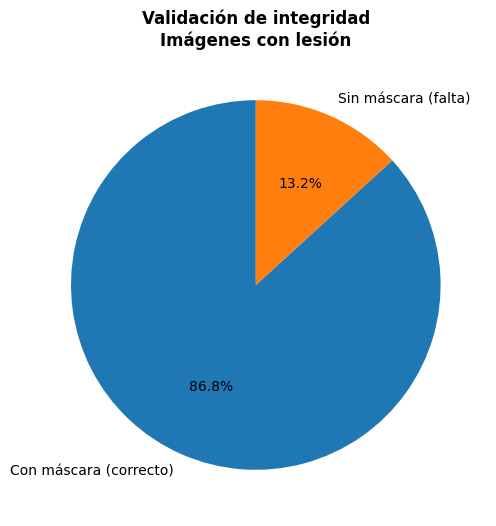


RESUMEN DE INTEGRIDAD
--------------------------------------------------
Total IDs en metadata        : 510
NORM (sin lesión)            : 0
   └─ con máscara (error)    : 0
Con lesión                   : 310
   └─ con máscara (ok)       : 269
   └─ sin máscara (falta)    : 41


In [ ]:
# calcular valores
norm_total = len(norm_ids)
norm_con = len(norm_con_mascara)
norm_sin = max(norm_total - norm_con, 0)

lesion_con = len(lesion_con_mascara)
lesion_sin = len(lesion_sin_mascara)

# estudio 
print("- ESTUDIO:")
print(f"  - NORM total: {norm_total}")
print(f"  - NORM con máscara: {norm_con}")
print(f"  - NORM sin máscara: {norm_sin}")
print(f"  - Lesión con máscara: {lesion_con}")
print(f"  - Lesión sin máscara: {lesion_sin}")

# funcion segura 
def safe_pie(values, labels, title):
    total = sum(values)
    
    plt.figure(figsize=(6,6))
    
    if total == 0:
        plt.text(0.5, 0.5, "Sin datos", ha='center', va='center', fontsize=12)
    else:
        plt.pie(
            values,
            labels=labels,
            autopct="%1.1f%%",
            startangle=90
        )
    
    plt.title(title, fontweight="bold")
    plt.show()

# grafica lesiones
safe_pie(
    [lesion_con, lesion_sin],
    ["Con máscara (correcto)", "Sin máscara (falta)"],
    "Validación de integridad\nImágenes con lesión"
)

# resumen
print("\nRESUMEN DE INTEGRIDAD")
print("-" * 50)
print(f"Total IDs en metadata        : {df['image_id'].nunique()}")
print(f"NORM (sin lesión)            : {norm_total}")
print(f"   └─ con máscara (error)    : {norm_con}")
print(f"Con lesión                   : {len(lesion_ids)}")
print(f"   └─ con máscara (ok)       : {lesion_con}")
print(f"   └─ sin máscara (falta)    : {lesion_sin}")

### **EMPAREJAMIENTO DE IMÁGENES**

Mostrando 5 casos aleatorios de 269 emparejados
------------------------------------------------------------


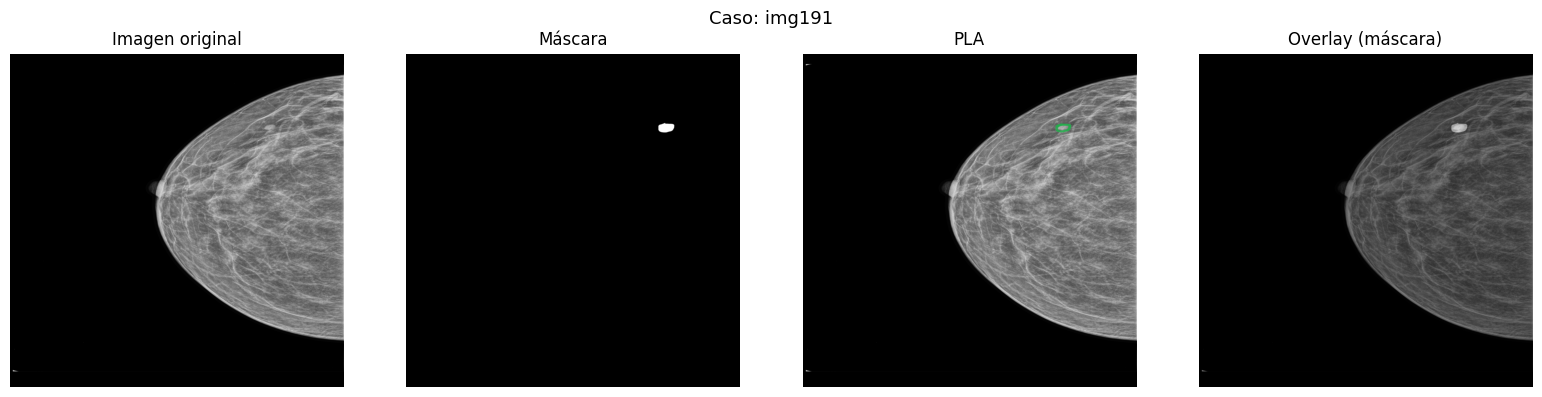

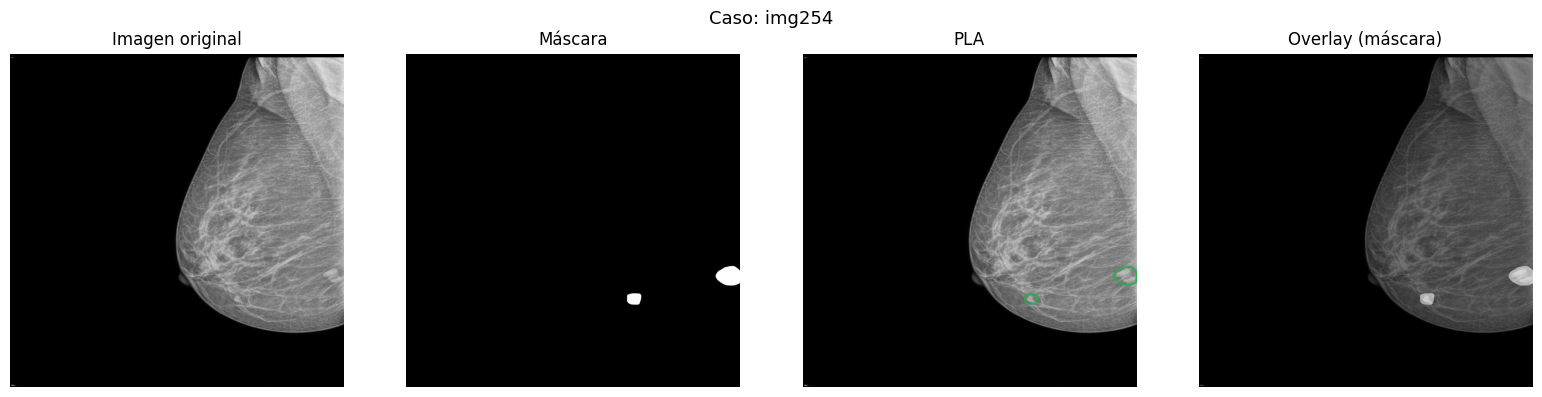

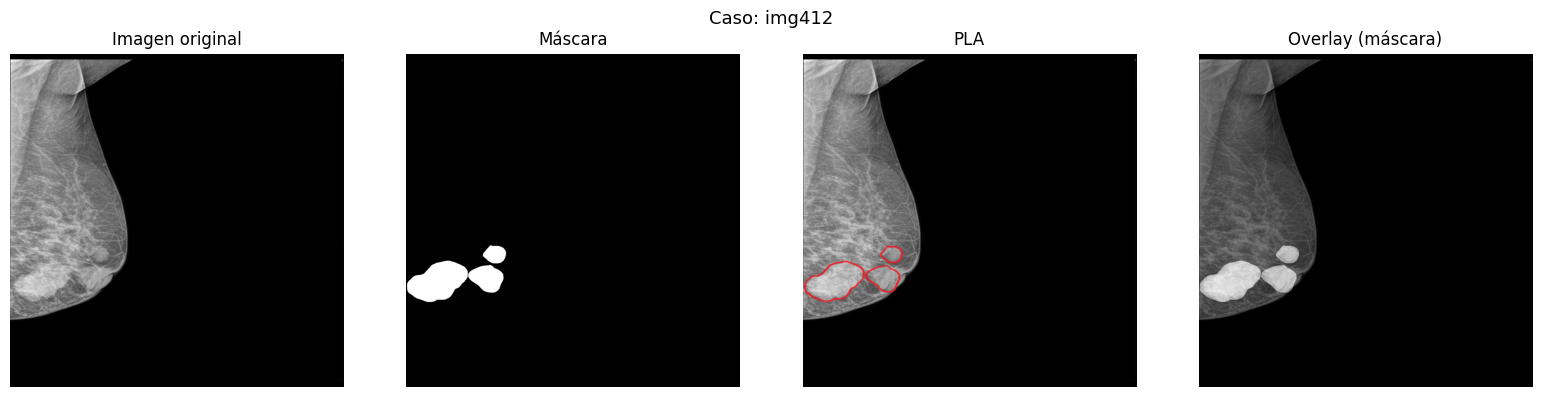

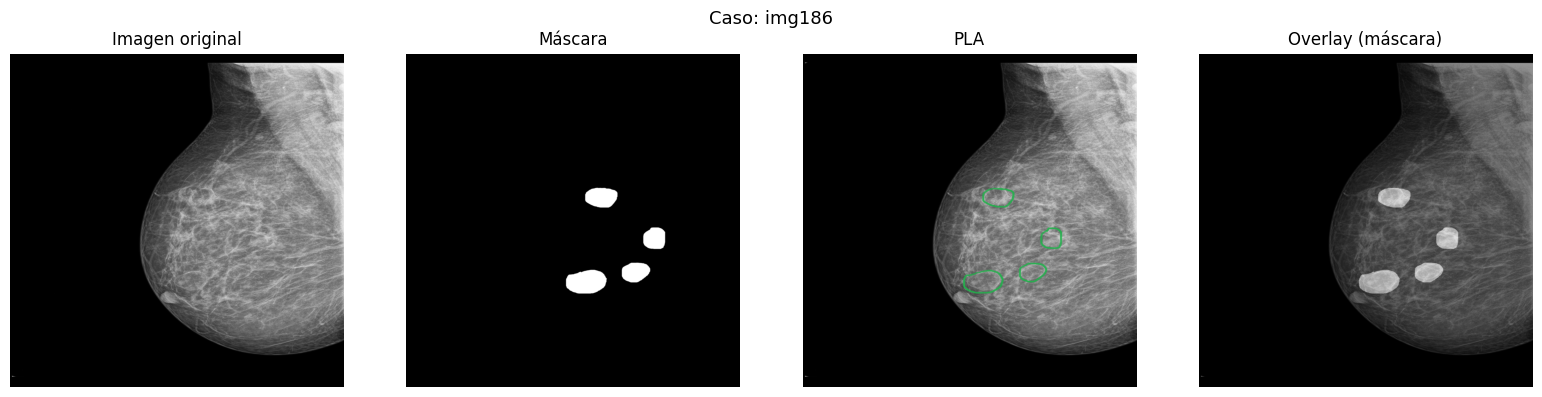

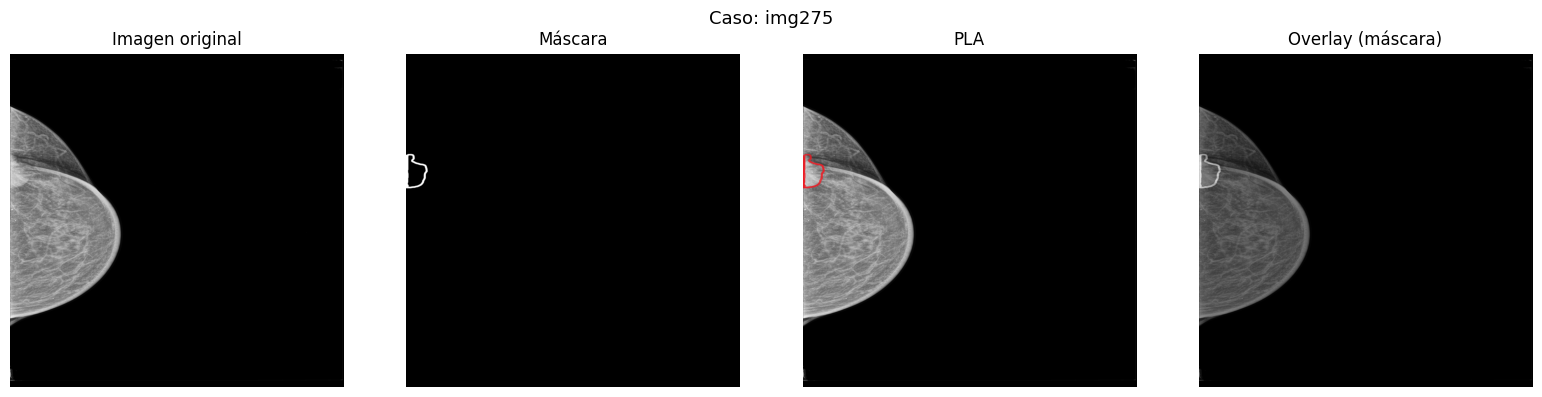

In [ ]:
def show_case(p):
    """Muestra imagen original, máscara, PLA y overlay para un caso dado."""
    img  = np.array(Image.open(p["image"]))
    mask = np.array(Image.open(p["mask"]))
    pla  = np.array(Image.open(p["pla"]))

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img,  cmap="gray");  ax[0].set_title("Imagen original"); ax[0].axis("off")
    ax[1].imshow(mask, cmap="gray");  ax[1].set_title("Máscara");         ax[1].axis("off")
    ax[2].imshow(pla,  cmap="gray");  ax[2].set_title("PLA");             ax[2].axis("off")

    ax[3].imshow(img,  cmap="gray")
    ax[3].imshow(mask, cmap="jet", alpha=0.4)
    ax[3].set_title("Overlay (máscara)"); ax[3].axis("off")

    plt.suptitle(f"Caso: {p['id']}", fontsize=13)
    plt.tight_layout()
    plt.show()


print(f"Mostrando 5 casos aleatorios de {len(pairs)} emparejados")
print("-" * 60)

for p in random.sample(pairs, min(5, len(pairs))):
    show_case(p)

### **ESTADÍSTICAS GENERALES**

ESTADÍSTICAS DE INTENSIDAD (píxeles)
----------------------------------------
  Min  : 0
  Max  : 255
  Media: 89.43
  Std  : 107.02


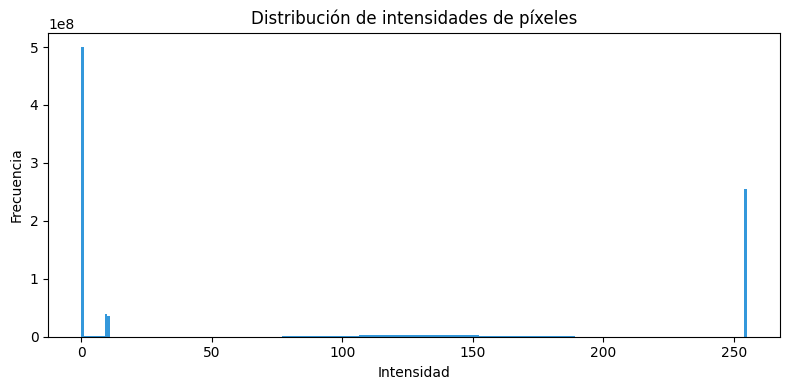

In [ ]:
pixel_values = np.concatenate(
    [np.array(Image.open(p["image"])).flatten() for p in pairs]
)

print("ESTADÍSTICAS DE INTENSIDAD (píxeles)")
print("-" * 40)
print(f"  Min  : {pixel_values.min()}")
print(f"  Max  : {pixel_values.max()}")
print(f"  Media: {pixel_values.mean():.2f}")
print(f"  Std  : {pixel_values.std():.2f}")

plt.figure(figsize=(8, 4))
plt.hist(pixel_values, bins=256, color="#3498db", edgecolor="none")
plt.title("Distribución de intensidades de píxeles")
plt.xlabel("Intensidad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [ ]:
# Tamaños únicos de imagen
sizes = {tuple(np.array(Image.open(p["image"])).shape) for p in pairs}
print("TAMAÑOS DE IMAGEN encontrados:")
for s in sorted(sizes):
    print(f"  {s}")

TAMAÑOS DE IMAGEN encontrados:
  (1024, 1024)
  (1024, 1024, 3)
  (1024, 1024, 4)


COBERTURA DE LESIONES (% píxeles con lesión)
----------------------------------------
  Media : 26.30%
  Min   : 0.20%
  Max   : 53.18%


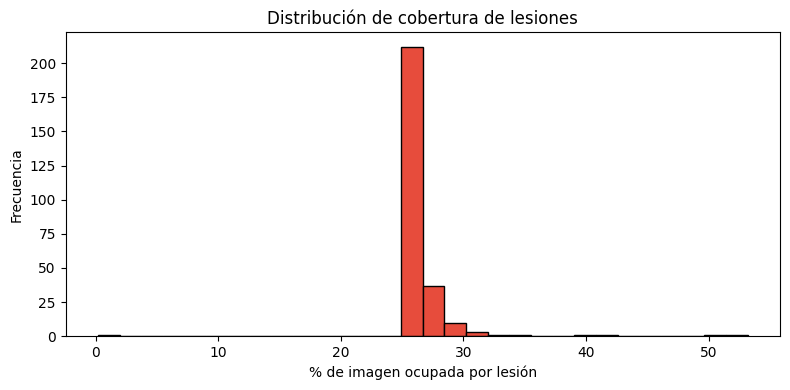

In [ ]:
coverages = np.array([
    (np.array(Image.open(p["mask"])) > 0).mean()
    for p in pairs
])

print("COBERTURA DE LESIONES (% píxeles con lesión)")
print("-" * 40)
print(f"  Media : {coverages.mean()*100:.2f}%")
print(f"  Min   : {coverages.min()*100:.2f}%")
print(f"  Max   : {coverages.max()*100:.2f}%")

plt.figure(figsize=(8, 4))
plt.hist(coverages * 100, bins=30, color="#e74c3c", edgecolor="black")
plt.title("Distribución de cobertura de lesiones")
plt.xlabel("% de imagen ocupada por lesión")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Ejemplo con MENOR cobertura de lesión:


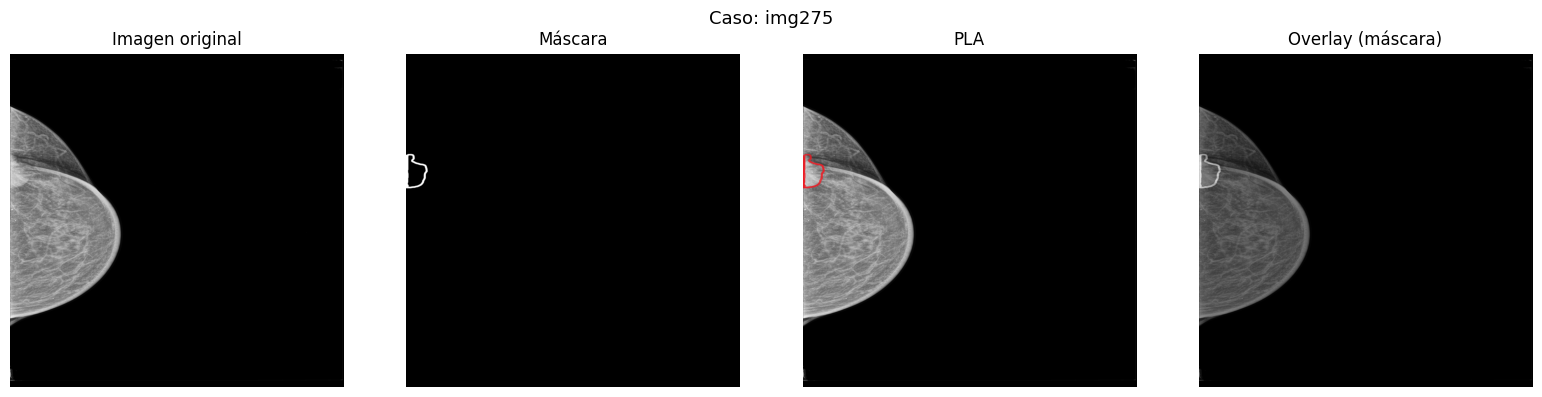

Ejemplo con MAYOR cobertura de lesión:


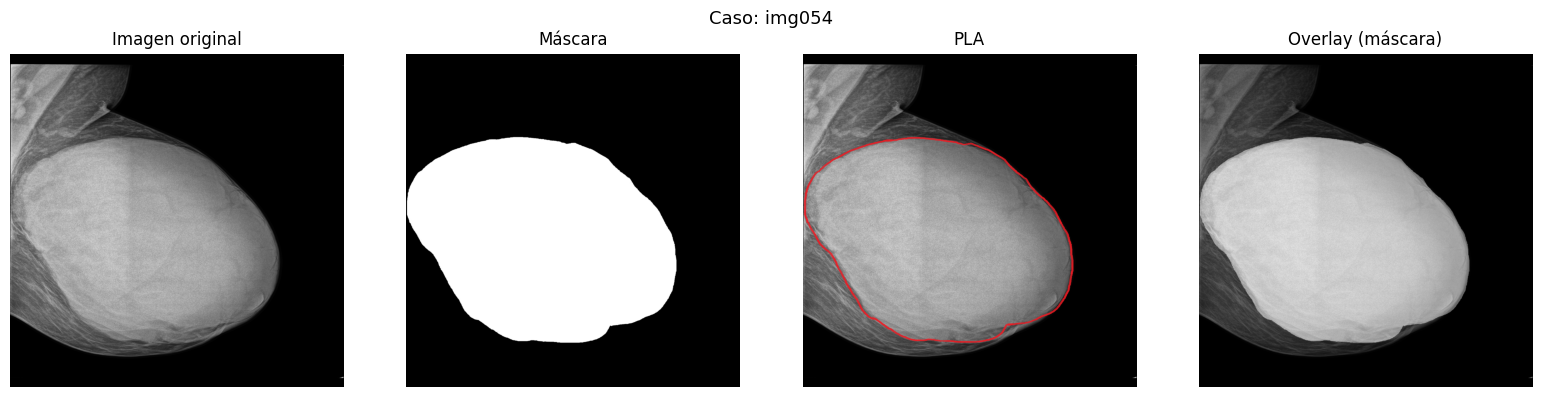

In [ ]:
# Casos extremos: menor y mayor cobertura
print("Ejemplo con MENOR cobertura de lesión:")
show_case(pairs[np.argmin(coverages)])

print("Ejemplo con MAYOR cobertura de lesión:")
show_case(pairs[np.argmax(coverages)])

Registros con anotaciones completas: 443 de 647 (68.5%)

  X      → Min: 28.0  Max: 4697.0  Media: 2219.8
  Y      → Min: 680.0  Max: 35561.0  Media: 3011.3
  Radius → Min: 20.0  Max: 2355.0  Media: 291.6  Std: 236.0


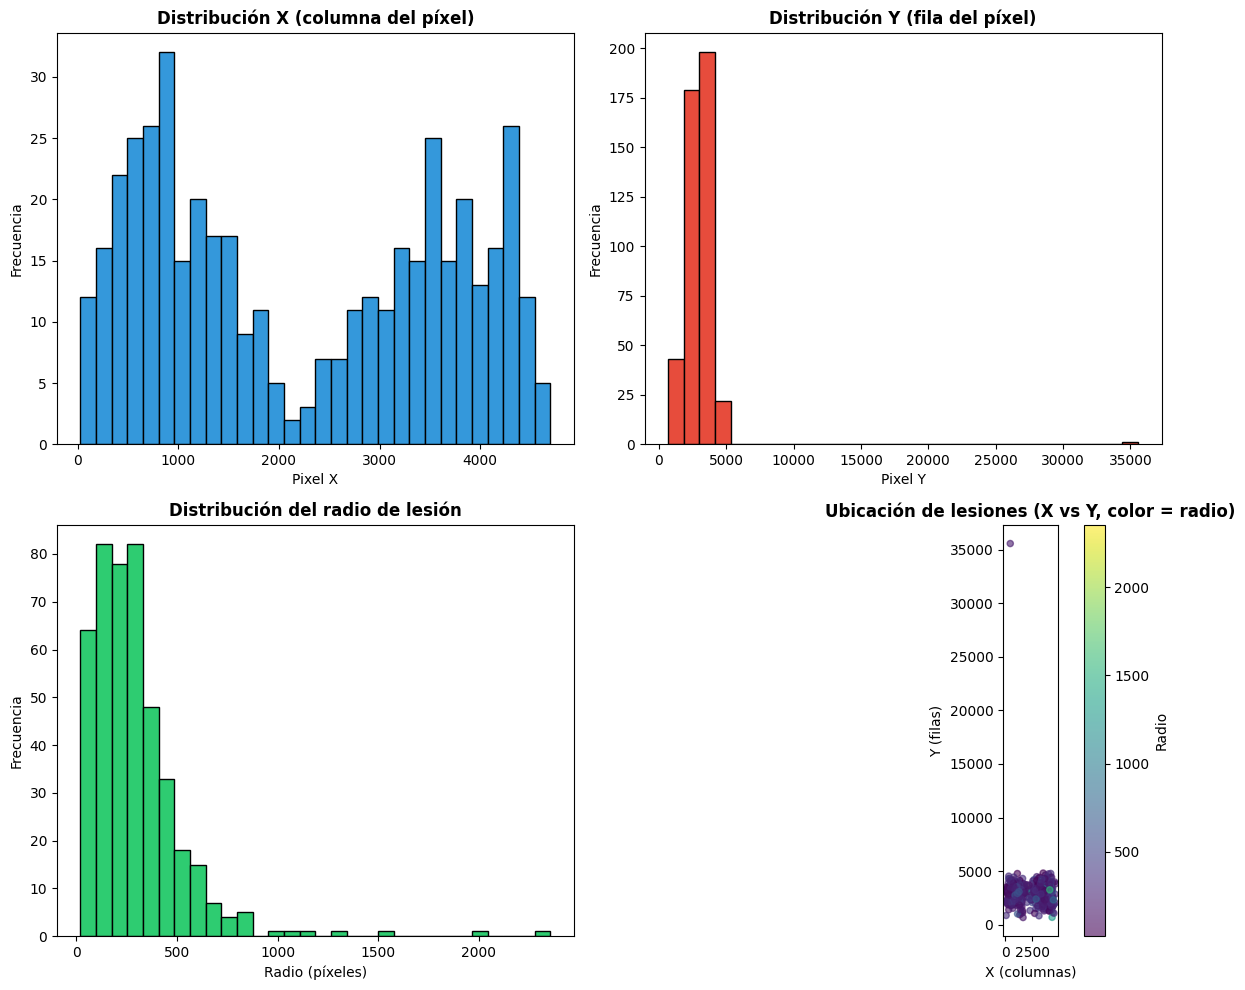

In [ ]:
annotations = df[
    (df["class"] != "NORM") &
    df["x"].notna() & df["y"].notna() & df["radius"].notna()
].copy()

print(f"Registros con anotaciones completas: {len(annotations)} de {len(df)} ({len(annotations)/len(df)*100:.1f}%)")
print()
print(f"  X      → Min: {annotations['x'].min():.1f}  Max: {annotations['x'].max():.1f}  Media: {annotations['x'].mean():.1f}")
print(f"  Y      → Min: {annotations['y'].min():.1f}  Max: {annotations['y'].max():.1f}  Media: {annotations['y'].mean():.1f}")
print(f"  Radius → Min: {annotations['radius'].min():.1f}  Max: {annotations['radius'].max():.1f}  Media: {annotations['radius'].mean():.1f}  Std: {annotations['radius'].std():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(annotations["x"], bins=30, color="#3498db", edgecolor="black")
axes[0, 0].set_title("Distribución X (columna del píxel)", fontweight="bold")
axes[0, 0].set_xlabel("Pixel X"); axes[0, 0].set_ylabel("Frecuencia")

axes[0, 1].hist(annotations["y"], bins=30, color="#e74c3c", edgecolor="black")
axes[0, 1].set_title("Distribución Y (fila del píxel)", fontweight="bold")
axes[0, 1].set_xlabel("Pixel Y"); axes[0, 1].set_ylabel("Frecuencia")

axes[1, 0].hist(annotations["radius"], bins=30, color="#2ecc71", edgecolor="black")
axes[1, 0].set_title("Distribución del radio de lesión", fontweight="bold")
axes[1, 0].set_xlabel("Radio (píxeles)"); axes[1, 0].set_ylabel("Frecuencia")

sc = axes[1, 1].scatter(
    annotations["x"], annotations["y"],
    c=annotations["radius"], cmap="viridis", alpha=0.6, s=20
)
axes[1, 1].set_title("Ubicación de lesiones (X vs Y, color = radio)", fontweight="bold")
axes[1, 1].set_xlabel("X (columnas)"); axes[1, 1].set_ylabel("Y (filas)")
axes[1, 1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1, 1], label="Radio")

plt.tight_layout()
plt.show()

         Columna  Complitud (%)  Missing
        image_id     100.000000        0
            view     100.000000        0
          tissue     100.000000        0
abnormality_type     100.000000        0
           class      69.088099      200
               x      68.778980      202
               y      68.778980      202
          radius      68.469861      204


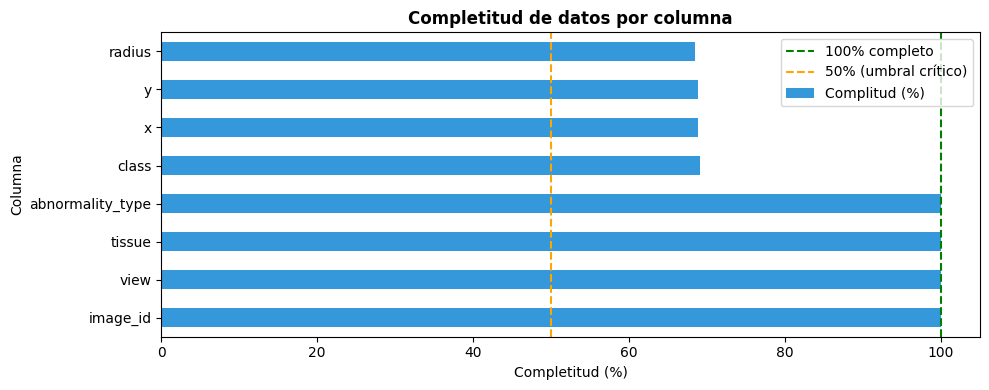


- Columnas con valores faltantes:
   - class: 200 faltantes (30.9% missing)
   - x: 202 faltantes (31.2% missing)
   - y: 202 faltantes (31.2% missing)
   - radius: 204 faltantes (31.5% missing)


In [ ]:
completeness_df = pd.DataFrame({
    "Columna"      : df.columns,
    "Complitud (%)" : (df.notna().sum() / len(df) * 100).values,
    "Missing"      : df.isna().sum().values
}).sort_values("Complitud (%)", ascending=False)

print(completeness_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
completeness_df.plot(x="Columna", y="Complitud (%)", kind="barh", ax=ax, legend=False, color="#3498db")
ax.axvline(x=100, color="green",  linestyle="--", linewidth=1.5, label="100% completo")
ax.axvline(x=50,  color="orange", linestyle="--", linewidth=1.5, label="50% (umbral crítico)")
ax.set_xlabel("Completitud (%)")
ax.set_title("Completitud de datos por columna", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

missing_cols = completeness_df[completeness_df["Complitud (%)"] < 100]
if missing_cols.empty:
    print("\n- Todas las columnas están completas.")
else:
    print("\n- Columnas con valores faltantes:")
    for _, row in missing_cols.iterrows():
        print(f"   - {row['Columna']}: {row['Missing']} faltantes ({100 - row['Complitud (%)']:.1f}% missing)")

Tabla cruzada – Clase vs Abnormality Type:
abnormality_type  ARCH  ARCH + CALC  ARCH+CALC  ARCH+CLAC  ASYM  CALC  \
class                                                                   
B                    0            0          2          0     1    65   
M                    2            0          2          1     2    13   
N                    2            1          2          0     3     2   
All                  4            1          6          1     6    80   

abnormality_type  CALC+CIRC  CALC+MISC  CIRC  CIRC + CALC  CIRC+CALC  \
class                                                                  
B                         0          0   160            0         15   
M                         1          3    14            3          1   
N                         0          0     4            0          0   
All                       1          3   178            3         16   

abnormality_type  CIRC+SPIC  MISC  MISC + CALC  MISC + SPIC  MISC+CALC  SPIC  \
class

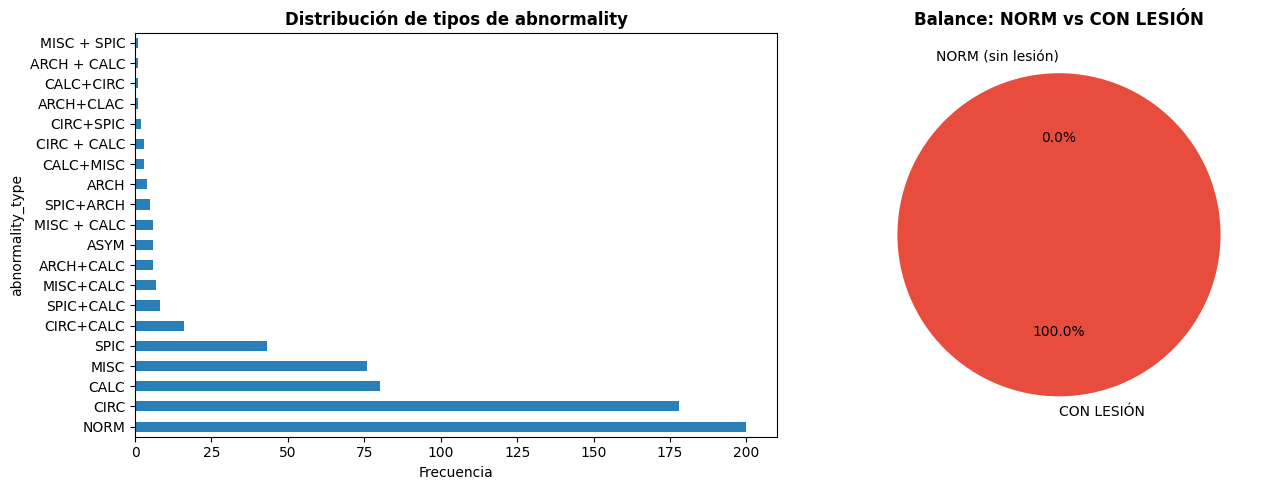


Desglose por clase:

  M: 158 registros
    Abnormality types   : {'MISC': 44, 'SPIC': 43, 'CIRC': 14, 'CALC': 13, 'SPIC+CALC': 8, 'MISC+CALC': 7, 'MISC + CALC': 6, 'SPIC+ARCH': 5, 'CALC+MISC': 3, 'CIRC + CALC': 3, 'CIRC+SPIC': 2, 'ARCH+CALC': 2, 'ASYM': 2, 'ARCH': 2, 'ARCH+CLAC': 1, 'CALC+CIRC': 1, 'MISC + SPIC': 1, 'CIRC+CALC': 1}
    Completitud radius  : 98.1%

  B: 253 registros
    Abnormality types   : {'CIRC': 160, 'CALC': 65, 'CIRC+CALC': 15, 'MISC': 10, 'ARCH+CALC': 2, 'ASYM': 1}
    Completitud radius  : 100.0%

  N: 36 registros
    Abnormality types   : {'MISC': 22, 'CIRC': 4, 'ASYM': 3, 'CALC': 2, 'ARCH+CALC': 2, 'ARCH': 2, 'ARCH + CALC': 1}
    Completitud radius  : 97.2%


In [ ]:
print("Tabla cruzada – Clase vs Abnormality Type:")
crosstab = pd.crosstab(df["class"], df["abnormality_type"], margins=True)
print(crosstab)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: distribución de abnormality (excluyendo NORM)
ab_counts = df[df["class"] != "NORM"]["abnormality_type"].value_counts()
ab_counts.plot(kind="barh", ax=axes[0], color="#2980b9")
axes[0].set_title("Distribución de tipos de abnormality", fontweight="bold")
axes[0].set_xlabel("Frecuencia")

# Pie: NORM vs lesión
norm_vs_lesion = pd.Series({"NORM (sin lesión)": len(norm_ids), "CON LESIÓN": len(lesion_ids)})
axes[1].pie(norm_vs_lesion, labels=norm_vs_lesion.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Balance: NORM vs CON LESIÓN", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nDesglose por clase:")
for cls in df["class"].dropna().unique():
    subset = df[df["class"] == cls]
    print(f"\n  {cls}: {len(subset)} registros")
    print(f"    Abnormality types   : {subset['abnormality_type'].value_counts().to_dict()}")
    print(f"    Completitud radius  : {subset['radius'].notna().sum() / len(subset) * 100:.1f}%")